In [27]:
!pip install qiskit qiskit-aer --quiet

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace, entropy, Operator

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Architecture (revised, May 2026):
#   - N_BH qubits: black hole register, starts fully occupied
#   - Radiation register: starts EMPTY, grows by 1 qubit per emission step
#   - No separate ENV register — radiation IS the environment
#   - Emitted qubits accumulate memory via collision-model inter-ancilla
#     interactions (Lorenzo, Ciccarello & Palma 2017) and back-act on BH
#   - Global statevector: fixed 2^N_BH dimension throughout (pure state)
#
# Primary observable: S_BH = von Neumann entropy of BH register
#   - Markovian: S(BH) falls due to Hilbert-space shrinking; S(R) monotonic
#   - Non-Markovian: S(BH) shows Page-curve-like recovery; S(R) peaks+falls
#
# Markovian model: numpy density matrix + depolarising Kraus channel (p=1)
#   - Qubit 0 fully decohered each step: information DESTROYED, not transferred
#   - S(radiation) = cumulative entropy emitted = monotonically increasing
#   - This is the GKSL Lindblad limit in discrete time
#
# Page time = N_BH // 2

N_BH = 12          # black hole size (14 exceeds available RAM for statevector)
C_M  = '#1A6FB5'   # Markovian colour
C_NM = '#E06000'   # Non-Markovian colour

print(f"Setup: N_BH={N_BH}, N_RAD_initial=0, Page time ≈ step {N_BH//2}")
print(f"Radiation register grows from 0 to {N_BH} qubits over evaporation.")

Setup: N_BH=12, N_RAD_initial=0, Page time ≈ step 6
Radiation register grows from 0 to 12 qubits over evaporation.


In [29]:
G0_GLOBAL = 0.785

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCUIT BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

def scramble_black_hole(qc, bh):
    """
    Fast-scrambler dynamics on BH register.
    Random layered two-qubit gates implement approximate Haar-random unitary
    (unitary k-design at polynomial depth; Harrow & Low 2009, Brandao et al 2016).
    Models the black hole's own chaotic Hamiltonian evolution.
    Black holes are conjectured to be fastest scramblers in nature (Sekino &
    Susskind 2008): t* ~ log(N_BH).
    """
    LAYERS = 1
    for _ in range(LAYERS):
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)
        if len(bh) > 1:
            for i in range(len(bh) - 1):
                qc.cx(bh[i], bh[i+1])
                qc.cz(bh[i], bh[i+1])
            for i in range(0, len(bh)-1, 2):
                qc.swap(bh[i], bh[i+1])
            if len(bh) > 3:
                qc.cx(bh[0], bh[-1])
                qc.cy(bh[1], bh[-2])


def radiation_memory_interaction(qc, rad):
    """
    Collision-model inter-ancilla interaction on radiation register.
    Previously emitted qubits interact with each other, building correlations
    in the radiation — this IS the non-Markovian memory mechanism.
    Implements the sum_k J_kn V_{A_k, A_n} term from the composite collision
    model (Lorenzo, Ciccarello & Palma 2017, Phys Rev A 96, 032107).
    """
    if len(rad) < 2:
        return
    for i in range(len(rad) - 1):
        qc.cx(rad[i], rad[i+1])
        qc.cz(rad[i+1], rad[i])
        qc.rx(np.random.uniform(0, 2*np.pi), rad[i])
        qc.ry(np.random.uniform(0, 2*np.pi), rad[i+1])
        qc.rz(np.random.uniform(0, 2*np.pi), rad[i])


def bh_radiation_backaction(qc, bh, rad):
    """
    BH-radiation back-action: accumulated radiation state feeds back into BH.
    This is the non-Markovian memory channel — information previously lost to
    radiation partially returns to the BH system. Violates CP-divisibility.
    """
    angle = np.pi/4
    for b in bh:
        for i, r in enumerate(rad):
            coupling = angle * np.exp(-0.3 * (len(rad) - 1 - i))
            qc.cz(b, r)          # Z-type: dephasing
            qc.cx(r, b)          # X-type: bit-flip back-action
            qc.rx(coupling, b)
            qc.ry(coupling, r)

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# KRYLOV SPREAD COMPLEXITY
# Trajectory-based Gram-Schmidt adaptation (no Hamiltonian)
# ─────────────────────────────────────────────────────────────────────────────
_krylov_basis = []

def _reset_krylov():
    global _krylov_basis
    _krylov_basis = []

def compute_spread_complexity(state_history):
    """
    Circuit-native Krylov spread complexity.
    Standard spread complexity (Balasubramanian et al 2022) requires a
    Hamiltonian to generate the Krylov basis via Lanczos recursion.
    Since this model is purely gate-based (no explicit Hamiltonian), we adapt:
    the Krylov basis {|b_n>} is built by incremental Gram-Schmidt
    orthogonalisation of the evolved statevector trajectory {|psi(t)>}.
    Spread complexity: K(t) = sum_n n |<b_n|psi(t)>|^2.
    Global statevector is fixed dimension 2^N_BH throughout — inner products
    are always well-defined.
    """
    global _krylov_basis
    for state in state_history[len(_krylov_basis):]:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        for b in _krylov_basis:
            vec -= np.vdot(b, vec) * b
        norm = np.linalg.norm(vec)
        if norm > 1e-10:
            _krylov_basis.append(vec / norm)
    complexities = []
    for state in state_history:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        k_t = sum(n * abs(np.vdot(b, vec))**2
                  for n, b in enumerate(_krylov_basis))
        complexities.append(k_t)
    return complexities

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# MARKOVIAN EVAPORATION — DEPOLARISING KRAUS CHANNEL
# ─────────────────────────────────────────────────────────────────────────────
# Physical content of Markovianity:
#   At each step, BH qubit 0 is subjected to a fully depolarising channel
#   (p=1). Kraus operators: {I/2, X/2, Y/2, Z/2}. Net effect: qubit 0
#   is decohered to the maximally mixed state I/2, all entanglement with
#   it destroyed. Information is DESTROYED, not transferred. This is the
#   GKSL Lindblad limit in discrete time — a memoryless, CP-divisible map.
#
#   After Kraus: trace out qubit 0 (BH shrinks). No back-action possible
#   because the channel is product at every step (fresh bath per emission).
#
#   Observable: S(BH) falls due to Hilbert-space shrinking (dimension halves
#   at each step — inevitable, not a Page curve). S(R_cumulative) = sum of
#   entropy emitted per step = monotonically increases to N_BH bits.
#   This monotonic S(R) is the Markovian signature.
# ─────────────────────────────────────────────────────────────────────────────

def vn_entropy_np(rho, base=2):
    ev = np.linalg.eigvalsh(rho)
    ev = ev[ev > 1e-12]
    return float(-np.sum(ev * np.log2(ev))) if base == 2 else float(-np.sum(ev * np.log(ev)))

def partial_trace_qubit0_np(rho, n_qubits):
    """Trace out qubit 0 from n_qubit numpy density matrix."""
    h = 2**(n_qubits - 1)
    return rho[:h, :h] + rho[h:, h:]

def run_markovian_evaporation():
    """
    Markovian BH evaporation.
    State: numpy density matrix (avoids 2^N x 2^N Qiskit DensityMatrix allocation).
    Scramble unitary obtained from Qiskit Operator on shrinking BH circuit.
    Depolarising Kraus (p=1) applied to qubit 0 each step.
    Tracks: S(BH), S(R_emitted_per_step), S(R_cumulative).
    """
    print("Starting Markovian Evaporation (depolarising Kraus, p=1)...")
    ent_bh, ent_rad_cumul, steps = [], [], []
    n_bh = N_BH
    rho = np.zeros((2**n_bh, 2**n_bh), dtype=complex)
    rho[0, 0] = 1.0   # |0...0><0...0|
    S_rad_total = 0.0

    I2 = np.eye(2, dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)
    paulis = [I2, X, Y, Z]

    for step in range(1, N_BH + 1):
        if n_bh == 0:
            break

        # 1. Scramble BH
        qc = QuantumCircuit(n_bh)
        scramble_black_hole(qc, list(range(n_bh)))
        U = Operator(qc).data
        rho = U @ rho @ U.conj().T

        # 2. Depolarising Kraus on qubit 0 (p=1, full decoherence)
        I_rest = np.eye(2**(n_bh-1), dtype=complex)
        kraus  = [np.kron(P, I_rest) / np.sqrt(4) for P in paulis]
        rho    = sum(K @ rho @ K.conj().T for K in kraus)

        # 3. Entropy of qubit 0 (emitted this step) before tracing out
        rho_reshaped = rho.reshape(2, 2**(n_bh-1), 2, 2**(n_bh-1))
        rho_q0 = np.einsum('iaja->ij', rho_reshaped)
        S_emitted = vn_entropy_np(rho_q0)
        S_rad_total += S_emitted

        # 4. Trace out qubit 0 — BH shrinks
        rho  = partial_trace_qubit0_np(rho, n_bh)
        n_bh -= 1

        S_BH = vn_entropy_np(rho) if n_bh > 0 else 0.0
        ent_bh.append(S_BH)
        ent_rad_cumul.append(S_rad_total)
        steps.append(step)

        print(f"[Markovian]     Step {step:2d}/{N_BH} | "
              f"S(BH)={S_BH:.4f} | S(R_cumul)={S_rad_total:.4f}")

    return steps, ent_bh, ent_rad_cumul

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# BH-RADIATION BACK-ACTION
# ─────────────────────────────────────────────────────────────────────────────
def bh_radiation_backaction(qc, bh, rad, t=None, N_BH_total=None, g0=G0_GLOBAL):
    """
    BH-radiation back-action with Hawking-temperature-motivated coupling.

    Coupling ansatz: g(t) = g0 / (1 - t/N_BH)
    motivated by T_H(t) ∝ 1/M(t) = 1/[N_BH(1 - t/N_BH)].
    Capped at π/2 to avoid rotation periodicity artifacts.
    Exponential decay with radiation distance retained from original model.

    Parameters
    ----------
    t           : current emission step (1-indexed)
    N_BH_total  : total number of BH qubits
    g0          : base coupling (free parameter, default π/8)
    """
    if t is not None and N_BH_total is not None:
        frac = t / N_BH_total
        # Avoid division by zero at final step
        if frac >= 1.0:
            frac = 1.0 - 1e-6
        hawking_factor = 1.0 / (1.0 - frac)
        base_angle = min(g0 * hawking_factor, np.pi / 2)
    else:
        base_angle = g0   # Use the global g0 if t or N_BH_total are not provided

    for b in bh:
        for i, r in enumerate(rad):
            coupling = base_angle * np.exp(-0.3 * (len(rad) - 1 - i))
            qc.cz(b, r)          # Z-type: dephasing
            qc.cx(r, b)          # X-type: bit-flip back-action
            qc.rx(coupling, b)
            qc.ry(coupling, r)

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-MARKOVIAN EVAPORATION — COLLISION MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Architecture:
#   Global pure statevector: fixed N_BH qubits throughout.
#   BH register [0..n_bh-1]: shrinks by 1 each step.
#   Radiation register [n_bh..N_BH-1]: grows by 1 each step.
#   Radiation = Environment: emitted qubits retained, inter-ancilla memory
#   interactions implemented (composite collision model, Lorenzo et al 2017).
#   Back-action: accumulated radiation feeds back into remaining BH —
#   this violates CP-divisibility => non-Markovian dynamical map.
#
# Primary observable: S_BH = vN entropy of BH register (Page curve quantity).
#   By purity of global state: S(BH) = S(R) at all times.
#   I(R:BH) = S(R) + S(BH) - S(RuBH) = S(R) + S(BH) [since S(RuBH)=0].
#   => I(R:BH) = 2*S(BH) exactly (verified below).
# ─────────────────────────────────────────────────────────────────────────────

def run_non_markovian_evaporation():
    _reset_krylov()
    print("Starting Non-Markovian Evaporation (collision model)...")

    current_state = Statevector.from_label('0' * N_BH)
    bh  = list(range(N_BH))
    rad = []
    ent_bh, ent_rad, mi, steps, state_history = [], [], [], [], []

    for step in range(1, N_BH + 1):
        # Build gate circuit (fixed N_BH-qubit Hilbert space)
        step_qc = QuantumCircuit(N_BH)



        # 1. Scramble BH register
        if len(bh) > 0:
            scramble_black_hole(step_qc, bh)

       # 2. Radiation memory: inter-ancilla collision model interactions
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)

        # 3. BH-radiation back-action (non-Markovian memory channel)
        if len(bh) > 0 and len(rad) > 0:
            #bh_radiation_backaction(step_qc, bh, rad)
             bh_radiation_backaction(step_qc, bh, rad, t=step, N_BH_total=N_BH, g0=G0_GLOBAL)


        # Evolve global statevector
        current_state = current_state.evolve(step_qc)
        state_history.append(current_state)

        # Emit: transfer bh[0] to radiation register
        emitted = bh.pop(0)
        rad.append(emitted)

        # Measure S(BH): trace out radiation
        if len(bh) > 0:
            rho_BH = partial_trace(current_state, rad)
            S_BH   = entropy(rho_BH, base=2)
            rho_R  = partial_trace(current_state, bh)
            S_R    = entropy(rho_R, base=2)
            # Pure global state: S(RuBH)=0 => I(R:BH) = S(R)+S(BH)
            I_RBH  = S_R + S_BH
        else:
            S_BH = S_R = I_RBH = 0.0

        ent_bh.append(S_BH)
        ent_rad.append(S_R)
        mi.append(I_RBH)
        steps.append(step)

        current_K = compute_spread_complexity(state_history)[-1]
        print(f"[Non-Markovian] Step {step:2d}/{N_BH} | "
              f"S(BH)={S_BH:.4f} | S(R)={S_R:.4f} | "
              f"K(t)={current_K:.4f} | I(R:BH)={I_RBH:.4f}")

    return steps, ent_bh, ent_rad, mi, state_history

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
s_m,  ebh_m,  erad_m                          = run_markovian_evaporation()
s_nm, ebh_nm, erad_nm, mi_nm, states_nm       = run_non_markovian_evaporation()

dS_bh_m  = np.diff(ebh_m)
dS_bh_nm = np.diff(ebh_nm)

_reset_krylov()
k_nm = compute_spread_complexity(states_nm)

page_idx  = np.argmax(mi_nm)
page_step = int(np.argmax(mi_nm)) + 1  # step number of peak I(R:BH)
print(f"\nPage time (peak I(R:BH)): step {page_step}")

Starting Markovian Evaporation (depolarising Kraus, p=1)...
[Markovian]     Step  1/12 | S(BH)=0.7865 | S(R_cumul)=1.0000
[Markovian]     Step  2/12 | S(BH)=1.7728 | S(R_cumul)=2.0000
[Markovian]     Step  3/12 | S(BH)=2.7485 | S(R_cumul)=3.0000
[Markovian]     Step  4/12 | S(BH)=3.7074 | S(R_cumul)=4.0000
[Markovian]     Step  5/12 | S(BH)=4.5955 | S(R_cumul)=5.0000
[Markovian]     Step  6/12 | S(BH)=5.1122 | S(R_cumul)=6.0000
[Markovian]     Step  7/12 | S(BH)=4.7518 | S(R_cumul)=7.0000
[Markovian]     Step  8/12 | S(BH)=3.9308 | S(R_cumul)=8.0000
[Markovian]     Step  9/12 | S(BH)=2.9805 | S(R_cumul)=9.0000
[Markovian]     Step 10/12 | S(BH)=1.9952 | S(R_cumul)=10.0000
[Markovian]     Step 11/12 | S(BH)=0.9991 | S(R_cumul)=11.0000
[Markovian]     Step 12/12 | S(BH)=0.0000 | S(R_cumul)=12.0000
Starting Non-Markovian Evaporation (collision model)...
[Non-Markovian] Step  1/12 | S(BH)=0.3393 | S(R)=0.3393 | K(t)=0.0000 | I(R:BH)=0.6786
[Non-Markovian] Step  2/12 | S(BH)=1.9992 | S(R)=1

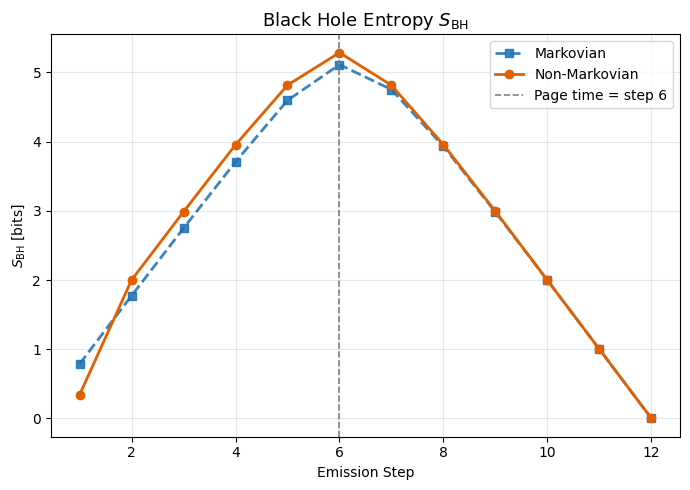

Saved: fig_sbh.pdf


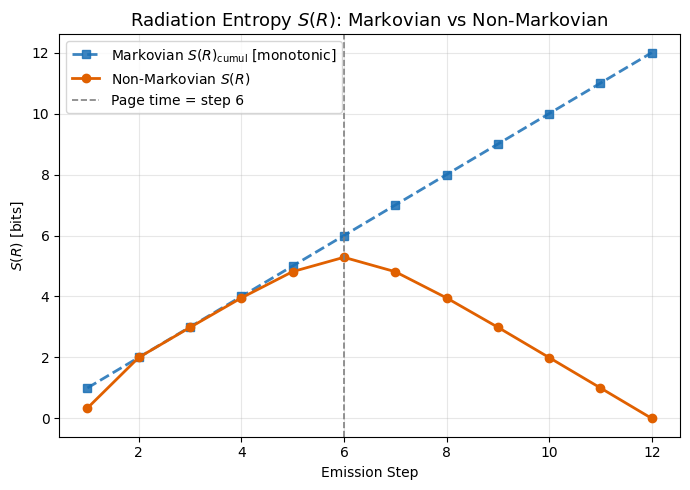

Saved: fig_sr.pdf


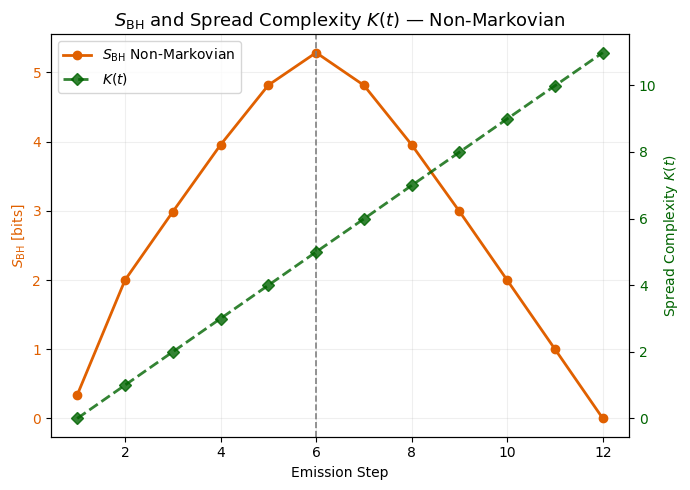

Saved: fig_complexity.pdf


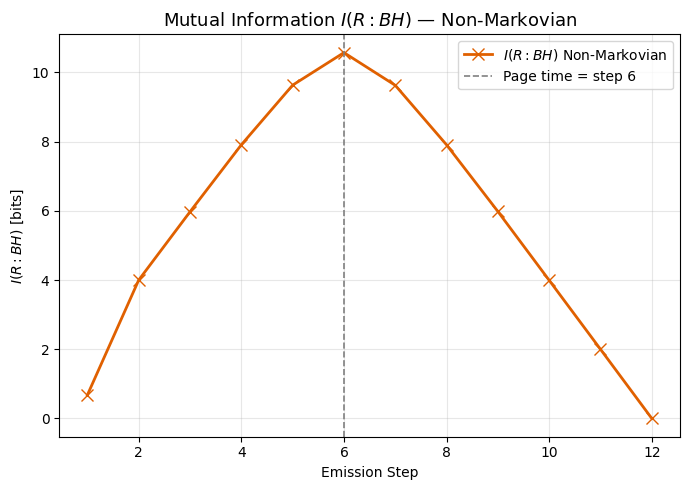

Saved: fig_mi.pdf


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# INDIVIDUAL FIGURES — same data as evaporation_results.pdf, split for paper
# ─────────────────────────────────────────────────────────────────────────────

# Fig 1: S(BH)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_m,  ebh_m,  's--', color=C_M,  lw=2, alpha=0.85, label='Markovian')
ax.plot(s_nm, ebh_nm, 'o-',  color=C_NM, lw=2,             label='Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2, label=f'Page time = step {page_step}')
ax.set_title(r'Black Hole Entropy $S_{\rm BH}$', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$S_{\rm BH}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sbh.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sbh.pdf')

# Fig 2: S(R)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_m,  erad_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian $S(R)_{\rm cumul}$ [monotonic]')
ax.plot(s_nm, erad_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian $S(R)$')
ax.axvline(page_step, color='gray', ls='--', lw=1.2, label=f'Page time = step {page_step}')
ax.set_title(r'Radiation Entropy $S(R)$: Markovian vs Non-Markovian', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$S(R)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sr.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sr.pdf')

# Fig 3: S(BH) + K(t)
fig, ax_s = plt.subplots(figsize=(7, 5))
ax_k = ax_s.twinx()
l1, = ax_s.plot(s_nm, ebh_nm, 'o-',  color=C_NM,       lw=2,
                label=r'$S_{\rm BH}$ Non-Markovian')
l2, = ax_k.plot(s_nm, k_nm,   'D--', color='darkgreen', lw=2, alpha=0.8,
                label=r'$K(t)$')
ax_s.axvline(page_step, color='gray', ls='--', lw=1.2)
ax_s.set_ylabel(r'$S_{\rm BH}$ [bits]', color=C_NM)
ax_s.tick_params(axis='y', labelcolor=C_NM)
ax_k.set_ylabel(r'Spread Complexity $K(t)$', color='darkgreen')
ax_k.tick_params(axis='y', labelcolor='darkgreen')
ax_s.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax_s.set_title(r'$S_{\rm BH}$ and Spread Complexity $K(t)$ — Non-Markovian', fontsize=13)
ax_s.set_xlabel('Emission Step'); ax_s.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_complexity.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_complexity.pdf')

# Fig 4: I(R:BH)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, mi_nm, 'x-', color=C_NM, lw=2, markersize=8,
        label=r'$I(R{:}BH)$ Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time = step {page_step}')
ax.set_title(r'Mutual Information $I(R{:}BH)$ — Non-Markovian', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$I(R{:}BH)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mi.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_mi.pdf')

## BLP Non-Markovianity Measure

**Protocol (Breuer, Laine & Piilo 2009):**
1. Prepare two initial BH states:  
   - Probe 1: $|0\rangle^{\otimes N_{\rm BH}}$  
   - Probe 2: $|{+}\rangle|0\rangle^{\otimes (N_{\rm BH}-1)}$
2. Evolve both through identical NM circuit (fixed random seed — isolates memory from randomness)
3. At each step: partial-trace radiation register → reduced BH state $\rho_{\rm BH}(t)$
4. Compute trace distance $D(t) = \frac{1}{2}\|\rho_1(t) - \rho_2(t)\|_1$
5. BLP measure: $\mathcal{N}_{\rm BLP} = \sum_{\Delta D > 0} \Delta D(t)$

$\mathcal{N}_{\rm BLP} > 0$ $\Leftrightarrow$ information backflow $\Leftrightarrow$ non-Markovian dynamics.

Computing BLP measure  (N_BH=10)...
Probe 1: |0>^N  |  Probe 2: |+>|0>^(N-1)
seed=42 — identical gate angles isolate memory effects.

Trace distances D(t):
  Step  1: D = 0.667083
  Step  2: D = 0.699746
  Step  3: D = 0.683571
  Step  4: D = 0.624153
  Step  5: D = 0.406698
  Step  6: D = 0.212548
  Step  7: D = 0.115778
  Step  8: D = 0.048240
  Step  9: D = 0.003479
  Step 10: D = 0.017278

BLP measure  N_BLP = 0.046462
→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).


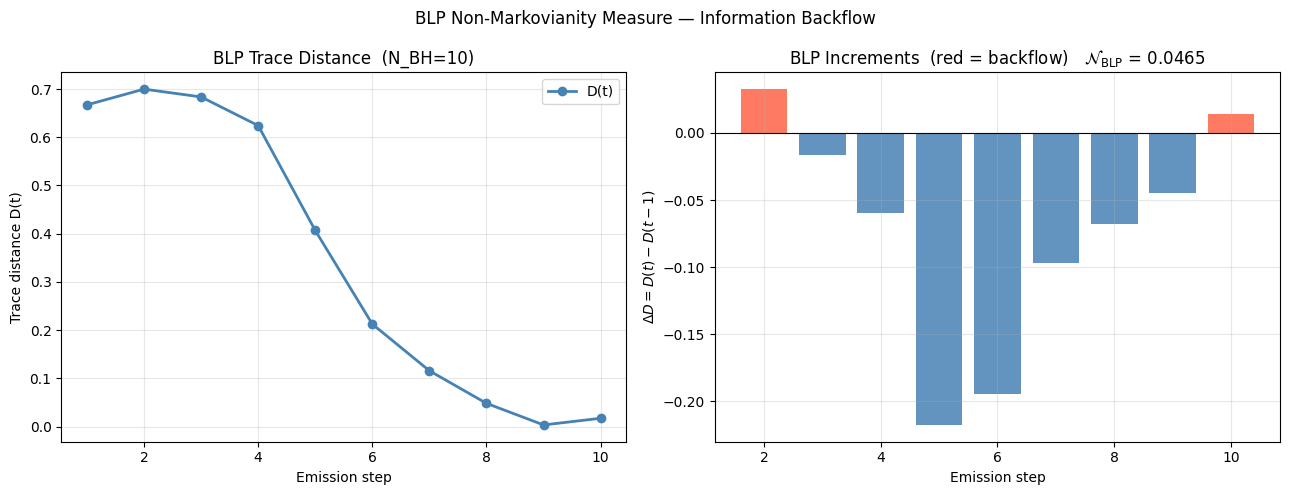

Saved: blp_measure.pdf


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP NON-MARKOVIANITY MEASURE
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
# ─────────────────────────────────────────────────────────────────────────────
N_BH = 10
def trace_distance(rho1, rho2) -> float:
    """D(rho1, rho2) = (1/2) Tr|rho1 - rho2| via eigenvalue decomposition."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))


#def run_evaporation_for_blp(probe: str, seed: int = 42):
def run_evaporation_for_blp(probe: str, seed: int = 42,
                             markovian: bool = False, g0: float = G0_GLOBAL):
    """
    BLP evaporation runner. Returns reduced BH density matrix rho_BH(t)
    at each step via partial trace over the radiation register.

    probe    : 'zero'      -> |0...0>^N_BH
               'plus'      -> |+>|0>^(N_BH-1)
               'ones'      -> |1...1>^N_BH
               'ones_last' -> |0...01>
               'plus_all'  -> |+>^N_BH
               'minus_all' -> |->^N_BH
    seed     : fixed RNG — identical gate angles for both probes isolates
               memory effect from circuit randomness.
    markovian: if True, disables radiation_memory_interaction and
               bh_radiation_backaction (pure scrambling control).
    g0       : base back-action coupling (Hawking-motivated ansatz).
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH          # 'zero'

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)

        if not markovian:
            if len(rad) >= 2:
                radiation_memory_interaction(step_qc, rad)
            if len(rad) > 0:
                bh_radiation_backaction(step_qc, bh, rad,
                                        t=step, N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_interior = partial_trace(state, rad)
        else:
            rho_interior = partial_trace(state, list(range(N_BH - 1)))
        rho_series.append(rho_interior)

    return rho_series


# ── Quick sanity check: single probe pair, seed=42 ───────────────────────────
print(f"Computing BLP measure  (N_BH={N_BH})...")
print(f"Probe 1: |0>^N  |  Probe 2: |+>|0>^(N-1)")
print(f"seed=42 — identical gate angles isolate memory effects.\n")

rho_series_1 = run_evaporation_for_blp('zero', seed=42, g0=G0_GLOBAL)
rho_series_2 = run_evaporation_for_blp('plus', seed=42, g0=G0_GLOBAL)

T         = min(len(rho_series_1), len(rho_series_2))
D_values  = [trace_distance(rho_series_1[t], rho_series_2[t]) for t in range(T)]
steps_blp = list(range(1, T + 1))
dD        = np.diff(D_values)
N_BLP     = float(np.sum(dD[dD > 0]))

print("Trace distances D(t):")
for t, d in zip(steps_blp, D_values):
    print(f"  Step {t:2d}: D = {d:.6f}")
print(f"\nBLP measure  N_BLP = {N_BLP:.6f}")
if N_BLP > 1e-6:
    print("→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).")
else:
    print("→ N_BLP ≈ 0 — no detectable backflow.")

# ── BLP plots ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(steps_blp, D_values, 'o-', color='steelblue', lw=2, label='D(t)')
axes[0].set_xlabel("Emission step")
axes[0].set_ylabel("Trace distance D(t)")
axes[0].set_title(f"BLP Trace Distance  (N_BH={N_BH})")
axes[0].grid(alpha=0.3); axes[0].legend()

bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
axes[1].bar(steps_blp[1:], dD, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel("Emission step")
axes[1].set_ylabel(r"$\Delta D = D(t) - D(t-1)$")
axes[1].set_title(
    f"BLP Increments  (red = backflow)   "
    r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
)
axes[1].grid(alpha=0.3)

plt.suptitle("BLP Non-Markovianity Measure — Information Backflow", fontsize=12)
plt.tight_layout()
plt.savefig("blp_measure.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_measure.pdf")

Computing BLP measure  (N_BH=10)...

────────────────────────────────────────────────────────────
Pair 1: non-orthogonal  [lower bound, D₀ ≈ 0.665]
Trace distances D(t):
  Step  1: D = 0.667083
  Step  2: D = 0.699746
  Step  3: D = 0.683571
  Step  4: D = 0.624153
  Step  5: D = 0.406698
  Step  6: D = 0.212548
  Step  7: D = 0.115778
  Step  8: D = 0.048240
  Step  9: D = 0.003479
  Step 10: D = 0.017278
N_BLP = 0.046462  →  non-Markovian confirmed

────────────────────────────────────────────────────────────
Pair 2: orthogonal (global flip)  [orthogonal, D₀ = 1.0]
Trace distances D(t):
  Step  1: D = 1.000000
  Step  2: D = 0.994439
  Step  3: D = 0.964973
  Step  4: D = 0.880175
  Step  5: D = 0.549353
  Step  6: D = 0.309448
  Step  7: D = 0.172157
  Step  8: D = 0.075798
  Step  9: D = 0.044952
  Step 10: D = 0.018409
N_BLP = 0.000000  →  no detectable backflow

────────────────────────────────────────────────────────────
Pair 3: orthogonal (single flip)  [orthogonal, D₀ = 1.0]
T

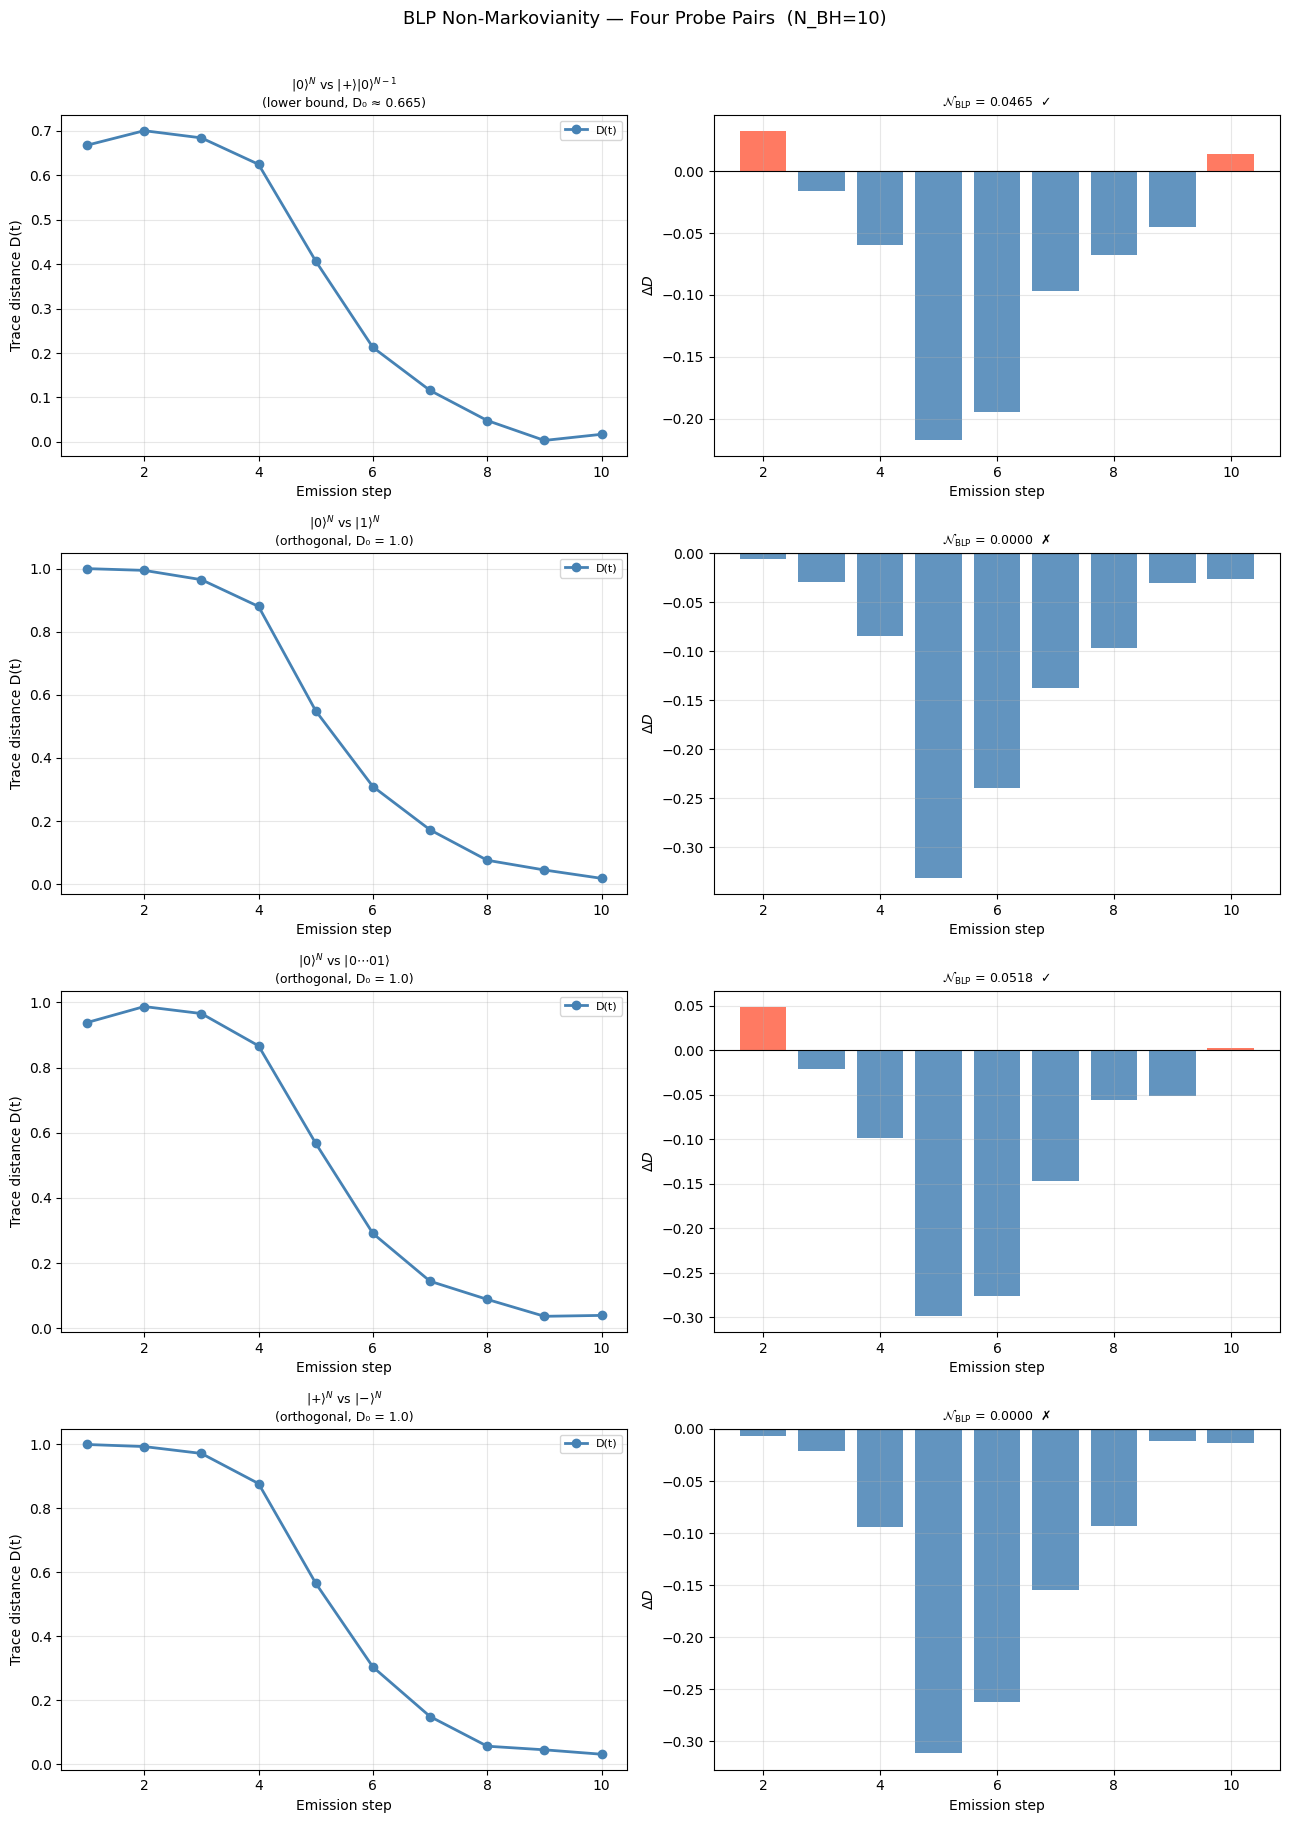

Saved: blp_measure.pdf


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP NON-MARKOVIANITY MEASURE
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
# ─────────────────────────────────────────────────────────────────────────────
N_BH = 10

def trace_distance(rho1, rho2) -> float:
    """D(rho1, rho2) = (1/2) Tr|rho1 - rho2| via eigenvalue decomposition."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))

'''
def run_evaporation_for_blp(probe: str, seed: int = 42, markovian: bool = False, g0: float = G0_GLOBAL):
    """
    probe : 'zero'     -> |0...0>^N
            'plus'     -> |+>|0>^(N-1)
            'ones'     -> |1...1>^N
            'ones_last'-> |0...01>
            'plus_all' -> |+>^N
            'minus_all'-> |->^N
    seed  : fixed — identical gate angles isolate memory effects.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH          # 'zero'

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    while len(bh) > 0:
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad, t=len(rad), N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_interior = partial_trace(state, rad)
        else:
            rho_interior = partial_trace(state, list(range(N_BH - 1)))
        rho_series.append(rho_interior)

    return rho_series
'''

def compute_blp_pair(probe_a, probe_b, label_a, label_b, series_cache):
    """Compute D(t), dD, N_BLP for a probe pair. Uses cache to avoid re-running."""
    if probe_a not in series_cache:
        series_cache[probe_a] = run_evaporation_for_blp(probe_a, seed=42, g0=G0_GLOBAL)
    if probe_b not in series_cache:
        series_cache[probe_b] = run_evaporation_for_blp(probe_b, seed=42, g0=G0_GLOBAL)
    s_a, s_b = series_cache[probe_a], series_cache[probe_b]
    T = min(len(s_a), len(s_b))
    D_vals = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
    steps  = list(range(1, T + 1))
    dD     = np.diff(D_vals)
    N_BLP  = float(np.sum(dD[dD > 0]))
    return steps, D_vals, dD, N_BLP


# ── Define all four pairs ─────────────────────────────────────────────────────
pairs = [
    ('zero', 'plus',      r"$|0\rangle^N$ vs $|{+}\rangle|0\rangle^{N-1}$",
                          "lower bound, D₀ ≈ 0.665",  "non-orthogonal"),
    ('zero', 'ones',      r"$|0\rangle^N$ vs $|1\rangle^N$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (global flip)"),
    ('zero', 'ones_last', r"$|0\rangle^N$ vs $|0\cdots01\rangle$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (single flip)"),
    ('plus_all','minus_all', r"$|{+}\rangle^N$ vs $|{-}\rangle^N$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (coherent)"),
]

# ── Run all pairs ─────────────────────────────────────────────────────────────
print(f"Computing BLP measure  (N_BH={N_BH})...")
cache   = {}
results = []

for i, (pa, pb, tex_label, d0_note, short) in enumerate(pairs, 1):
    print(f"\n{'─'*60}")
    print(f"Pair {i}: {short}  [{d0_note}]")
    steps, D_vals, dD, N_BLP = compute_blp_pair(pa, pb, pa, pb, cache)
    results.append((steps, D_vals, dD, N_BLP, tex_label, d0_note))

    print("Trace distances D(t):")
    for t, d in zip(steps, D_vals):
        print(f"  Step {t:2d}: D = {d:.6f}")
    print(f"N_BLP = {N_BLP:.6f}  →  {'non-Markovian confirmed' if N_BLP > 1e-6 else 'no detectable backflow'}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'Pair':<45} {'N_BLP':>10}")
print(f"  {'─'*45}  {'─'*8}")
for i, ((pa, pb, _, d0_note, short), (_, _, _, N_BLP, _, _)) in enumerate(zip(pairs, results), 1):
    flag = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<42} {N_BLP:>10.6f}  {flag}")
print(f"{'='*60}")

# ── 4×2 plot grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(13, 18))

for row, (steps, D_vals, dD, N_BLP, tex_label, d0_note) in enumerate(results):
    # Left: trace distance
    axes[row, 0].plot(steps, D_vals, 'o-', color='steelblue', lw=2, label='D(t)')
    axes[row, 0].set_xlabel("Emission step")
    axes[row, 0].set_ylabel("Trace distance D(t)")
    axes[row, 0].set_title(f"{tex_label}\n({d0_note})", fontsize=9)
    axes[row, 0].grid(alpha=0.3)
    axes[row, 0].legend(fontsize=8)

    # Right: ΔD bar chart
    bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
    axes[row, 1].bar(steps[1:], dD, color=bar_colors, alpha=0.85)
    axes[row, 1].axhline(0, color='black', lw=0.8)
    axes[row, 1].set_xlabel("Emission step")
    axes[row, 1].set_ylabel(r"$\Delta D$")
    axes[row, 1].set_title(
        r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
        + ("  ✓" if N_BLP > 1e-6 else "  ✗"),
        fontsize=9
    )
    axes[row, 1].grid(alpha=0.3)

plt.suptitle(
    f"BLP Non-Markovianity — Four Probe Pairs  (N_BH={N_BH})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("blp_measure.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_measure.pdf")

BLP Seed Robustness  (N_BH=10)
Seeds tested: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115]

Running Markovian control (memory terms disabled)...

Probe pair                           seed=5  seed=10  seed=15  seed=20  seed=25  seed=30  seed=35  seed=40  seed=45  seed=50  seed=55  seed=60  seed=65  seed=70  seed=75  seed=80  seed=85  seed=90  seed=95  seed=100  seed=105  seed=110  seed=115    mean ± std
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P1: |0>^N vs |+>|0>^(N-1)             0.00851   0.00524   0.03054   0.00000   0.01925   0.01051   0.00009   0.00000   0.00029   0.02040   0.01189   0.01341   0.04733   0.00920   0.00403   0.00000   0.02447   0.00226   0.03327   0.05386   0.05756   0.00436   0.00345    0.01565 ± 0.017

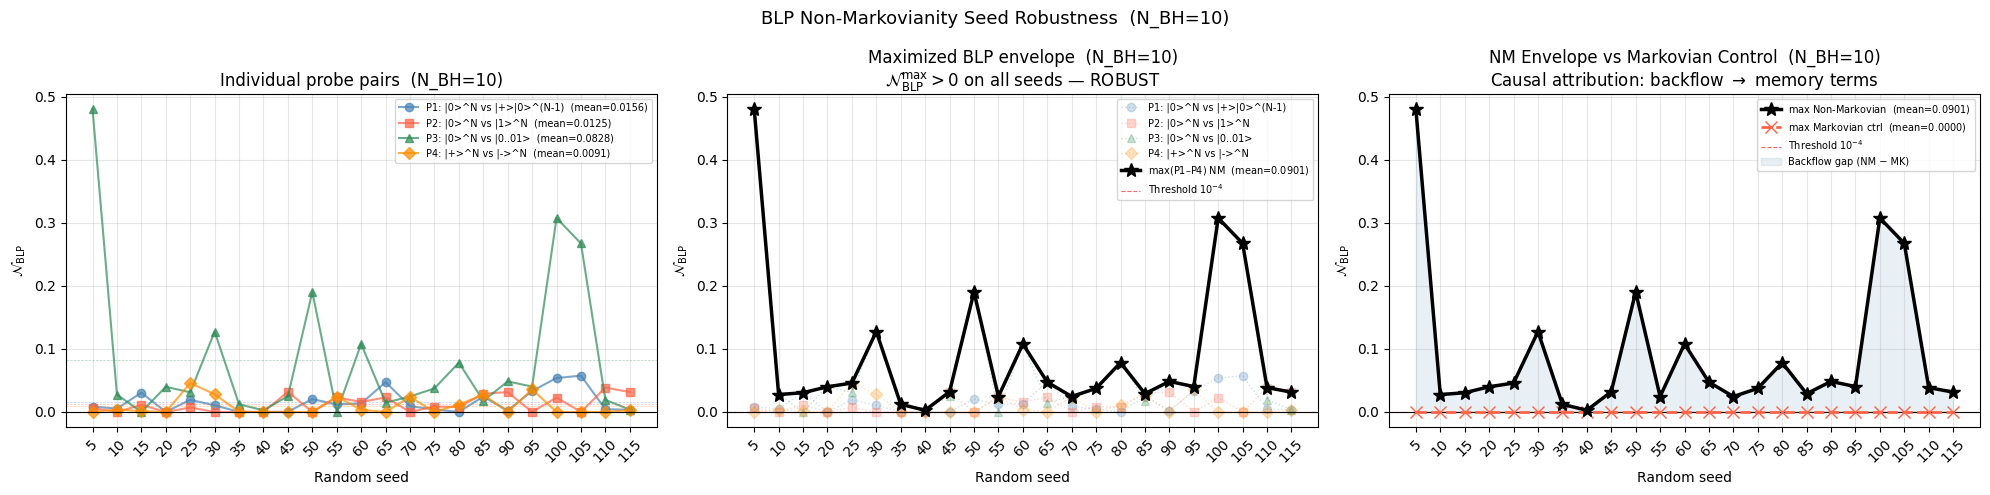

Saved: blp_seed_robustness.pdf


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP SEED ROBUSTNESS TABLE + MAXIMIZED ENVELOPE + MARKOVIAN CONTROL
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

SEEDS       = [i for i in range(5, 120, 5)]
PROBE_PAIRS = [
    ('zero',     'plus',      "P1: |0>^N vs |+>|0>^(N-1)"),
    ('zero',     'ones',      "P2: |0>^N vs |1>^N"),
    ('zero',     'ones_last', "P3: |0>^N vs |0..01>"),
    ('plus_all', 'minus_all', "P4: |+>^N vs |->^N"),
]

MAX_PAIRS = [('zero', 'plus'), ('zero', 'ones_last'),
             ('zero', 'ones'), ('plus_all', 'minus_all')]

print(f"BLP Seed Robustness  (N_BH={N_BH})")
print(f"Seeds tested: {SEEDS}\n")

# ── Per-pair non-Markovian table ──────────────────────────────────────────────
table = {}
for pa, pb, plabel in PROBE_PAIRS:
    table[plabel] = {}
    for seed in SEEDS:
        s_a = run_evaporation_for_blp(pa, seed=seed, g0=G0_GLOBAL)
        s_b = run_evaporation_for_blp(pb, seed=seed, g0=G0_GLOBAL)
        T   = min(len(s_a), len(s_b))
        D   = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD  = np.diff(D)
        table[plabel][seed] = float(np.sum(dD[dD > 0]))

# ── Maximized envelope ────────────────────────────────────────────────────────
maximized = {}
for seed in SEEDS:
    # Reuse values already computed — no need to re-run simulations
    p1_label = "P1: |0>^N vs |+>|0>^(N-1)"
    p2_label = "P2: |0>^N vs |1>^N"
    p3_label = "P3: |0>^N vs |0..01>"
    p4_label = "P4: |+>^N vs |->^N"
    maximized[seed] = max(
        table[p1_label][seed],
        table[p2_label][seed],
        table[p3_label][seed],
        table[p4_label][seed],
    )

max_vals   = np.array([maximized[s] for s in SEEDS])
max_mean   = max_vals.mean()
max_std    = max_vals.std()
max_robust = np.all(max_vals > 1e-4)

# ── Markovian control: maximized over same four pairs ─────────────────────────
print("Running Markovian control (memory terms disabled)...")
mk_table = {}
for pa, pb, plabel in PROBE_PAIRS:
    mk_table[plabel] = {}
    for seed in SEEDS:
        s_a = run_evaporation_for_blp(pa, seed=seed, markovian=True, g0=G0_GLOBAL)
        s_b = run_evaporation_for_blp(pb, seed=seed, markovian=True, g0=G0_GLOBAL)
        T   = min(len(s_a), len(s_b))
        D   = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD  = np.diff(D)
        mk_table[plabel][seed] = float(np.sum(dD[dD > 0]))

mk_maximized = {}
for seed in SEEDS:
    mk_maximized[seed] = max(
        mk_table[p1_label][seed],
        mk_table[p2_label][seed],
        mk_table[p3_label][seed],
        mk_table[p4_label][seed],
    )

mk_max_vals = np.array([mk_maximized[s] for s in SEEDS])
mk_mean     = mk_max_vals.mean()
mk_std      = mk_max_vals.std()

# ── Print raw table ───────────────────────────────────────────────────────────
header = f"{'Probe pair':<35}" + "".join(f"  seed={s}" for s in SEEDS) + "    mean ± std"
print(f"\n{header}")
print("─" * len(header))

summary = {}
for plabel, seed_vals in table.items():
    vals = np.array([seed_vals[s] for s in SEEDS])
    mean = vals.mean()
    std  = vals.std()
    summary[plabel] = (vals, mean, std)
    row  = f"{plabel:<35}"
    row += "".join(f"  {seed_vals[s]:>8.5f}" for s in SEEDS)
    row += f"    {mean:.5f} ± {std:.5f}"
    print(row)

row  = f"{'MAX(P1,P2,P3,P4) [NM]':<35}"
row += "".join(f"  {maximized[s]:>8.5f}" for s in SEEDS)
row += f"    {max_mean:.5f} ± {max_std:.5f}"
print(row)

row  = f"{'MAX(P1,P2,P3,P4) [MK]':<35}"
row += "".join(f"  {mk_maximized[s]:>8.5f}" for s in SEEDS)
row += f"    {mk_mean:.5f} ± {mk_std:.5f}"
print(row)

# ── Verdict ───────────────────────────────────────────────────────────────────
print("\nVerdict (N_BLP > 1e-4 on ALL seeds = robust):")
for plabel, (vals, mean, std) in summary.items():
    always_positive = np.all(vals > 1e-4)
    sometimes       = np.any(vals > 1e-4)
    if always_positive:
        verdict = "ROBUST  — positive on every seed"
    elif sometimes:
        verdict = "PARTIAL — positive on some seeds only"
    else:
        verdict = "NULL    — no backflow detected"
    print(f"  {plabel:<35} {verdict}")

print(f"  {'MAX [Non-Markovian]':<35} "
      f"{'ROBUST  — positive on every seed' if max_robust else 'PARTIAL — some seeds still zero'}")
mk_robust = np.all(mk_max_vals > 1e-4)
print(f"  {'MAX [Markovian ctrl]':<35} "
      f"{'ROBUST' if mk_robust else 'NULL / PARTIAL — as expected'}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

markers = ['o', 's', '^', 'D']
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# Panel 1: Individual non-Markovian pairs
ax = axes[0]
for (plabel, (vals, mean, std)), marker, color in zip(summary.items(), markers, colors):
    ax.plot(SEEDS, vals, marker=marker, color=color, lw=1.5, alpha=0.7,
            label=f"{plabel}  (mean={mean:.4f})")
    ax.axhline(mean, color=color, lw=0.5, ls='--', alpha=0.4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed")
ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"Individual probe pairs  (N_BH={N_BH})")
ax.set_xticks(SEEDS)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)

# Panel 2: Maximized envelope vs individual pairs (muted)
ax = axes[1]
for (plabel, (vals, mean, std)), marker, color in zip(summary.items(), markers, colors):
    ax.plot(SEEDS, vals, marker=marker, color=color, lw=1.0,
            alpha=0.25, ls=':', label=f"{plabel}")
ax.plot(SEEDS, max_vals, marker='*', color='black', lw=2.5, markersize=10,
        label=r"$\max$(P1–P4) NM  " + f"(mean={max_mean:.4f})",
        zorder=5)
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6, label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed")
ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    f"Maximized BLP envelope  (N_BH={N_BH})\n"
    + (r"$\mathcal{N}_{\rm BLP}^{\max} > 0$ on all seeds — ROBUST"
       if max_robust else
       r"$\mathcal{N}_{\rm BLP}^{\max}$ still zero on some seeds")
)
ax.set_xticks(SEEDS)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)

# Panel 3: Maximized NM envelope vs Maximized Markovian control
ax = axes[2]
ax.plot(SEEDS, max_vals,    marker='*', color='black',  lw=2.5, markersize=10,
        label=r"$\max$ Non-Markovian" + f"  (mean={max_mean:.4f})", zorder=5)
ax.plot(SEEDS, mk_max_vals, marker='x', color='tomato', lw=2.0, markersize=8,
        ls='--', label=r"$\max$ Markovian ctrl" + f"  (mean={mk_mean:.4f})", zorder=4)
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6, label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(SEEDS, mk_max_vals, max_vals,
                alpha=0.12, color='steelblue', label="Backflow gap (NM − MK)")
ax.set_xlabel("Random seed")
ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    f"NM Envelope vs Markovian Control  (N_BH={N_BH})\n"
    r"Causal attribution: backflow $\rightarrow$ memory terms"
)
ax.set_xticks(SEEDS)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)

plt.suptitle(f"BLP Non-Markovianity Seed Robustness  (N_BH={N_BH})", fontsize=13)
plt.tight_layout()
plt.savefig("blp_seed_robustness.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_seed_robustness.pdf")

## BLP Non-Markovianity with Varying Back-action Coupling `g0`

To investigate how to increase distinguishability (or information backflow), we can vary the `g0` parameter, which controls the strength of the `bh_radiation_backaction`. A larger `g0` implies stronger non-Markovian effects.

In [41]:
import math

# Define a range of g0 values to sweep
# Include values around and above pi/2 to see the capping effect
G0_SWEEP_VALUES = [
    0.001,           # Very small
    0.1,
    np.pi / 8,       # Common value in some contexts
    0.5,             # Current G0_GLOBAL
    np.pi / 4,
    np.pi / 2,       # The capping value
    0.75 * np.pi,    # Above the cap
    np.pi,           # Even further above the cap
]

# Using probe pair P3 for the sweep, as it showed the most interesting variability
SWEEP_PROBE_PAIR = ('zero', 'ones_last', "P3: $|0>^{N}$ vs $|0..01>$")
SWEEP_SEED       = 42 # Keep seed fixed to isolate g0 effect

print(f"Sweeping g0 values for probe pair: {SWEEP_PROBE_PAIR[2]} (seed={SWEEP_SEED})")
print(f"g0 values to test: {[f'{val:.3f}' for val in G0_SWEEP_VALUES]}")

blp_g0_results = {}

for g0_val in G0_SWEEP_VALUES:
    # Run evaporation for the specified probe pair with the current g0_val
    s_a = run_evaporation_for_blp(SWEEP_PROBE_PAIR[0], seed=SWEEP_SEED, g0=g0_val)
    s_b = run_evaporation_for_blp(SWEEP_PROBE_PAIR[1], seed=SWEEP_SEED, g0=g0_val)

    T = min(len(s_a), len(s_b))
    D_values = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
    dD = np.diff(D_values)
    N_BLP_val = float(np.sum(dD[dD > 0]))

    blp_g0_results[g0_val] = {
        'D_values': D_values,
        'N_BLP': N_BLP_val
    }
    print(f"  g0 = {g0_val:.3f}: N_BLP = {N_BLP_val:.6f}")

print("\nBLP N_BLP values for various g0:")
for g0, data in blp_g0_results.items():
    print(f"  g0 = {g0:.3f}: N_BLP = {data['N_BLP']:.6f}")


Sweeping g0 values for probe pair: P3: $|0>^{N}$ vs $|0..01>$ (seed=42)
g0 values to test: ['0.001', '0.100', '0.393', '0.500', '0.785', '1.571', '2.356', '3.142']
  g0 = 0.001: N_BLP = 0.002828
  g0 = 0.100: N_BLP = 0.007280
  g0 = 0.393: N_BLP = 0.046564
  g0 = 0.500: N_BLP = 0.048927
  g0 = 0.785: N_BLP = 0.051588
  g0 = 1.571: N_BLP = 0.051336
  g0 = 2.356: N_BLP = 0.051336
  g0 = 3.142: N_BLP = 0.051336

BLP N_BLP values for various g0:
  g0 = 0.001: N_BLP = 0.002828
  g0 = 0.100: N_BLP = 0.007280
  g0 = 0.393: N_BLP = 0.046564
  g0 = 0.500: N_BLP = 0.048927
  g0 = 0.785: N_BLP = 0.051588
  g0 = 1.571: N_BLP = 0.051336
  g0 = 2.356: N_BLP = 0.051336
  g0 = 3.142: N_BLP = 0.051336


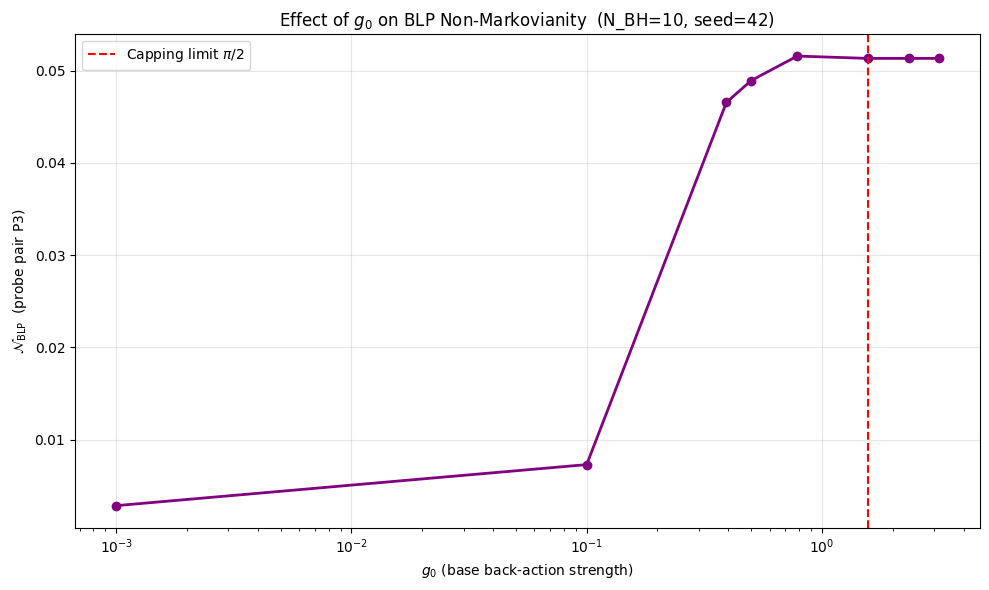

Saved: blp_g0_sweep.pdf


In [42]:
# Plotting the BLP N_BLP vs g0 values

g0_keys = list(blp_g0_results.keys())
n_blp_values = [blp_g0_results[g]['N_BLP'] for g in g0_keys]

plt.figure(figsize=(10, 6))
plt.plot(g0_keys, n_blp_values, 'o-', color='purple', lw=2)
plt.axvline(np.pi / 2, color='red', linestyle='--', label=r'Capping limit $\pi/2$')
plt.xlabel(r'$g_0$ (base back-action strength)')
plt.ylabel(r'$\mathcal{N}_{\rm BLP}$  (probe pair P3)')
plt.title(f'Effect of $g_0$ on BLP Non-Markovianity  (N_BH={N_BH}, seed={SWEEP_SEED})')
plt.grid(alpha=0.3)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_sweep.pdf")

In [43]:
def run_evaporation_for_blp_radiation(probe: str, seed: int = 42, g0: float = G0_GLOBAL):
    """Same as run_evaporation_for_blp but returns radiation reduced state."""
    np.random.seed(seed)
    # ... same initialisation ...

    step = 0
    while len(bh) > 0:
        step += 1
        # ... same circuit ...
        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)   # ← trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # full state is radiation
        rho_series.append(rho_rad)

    return rho_series

BH vs Radiation distinguishability diagnostic
Probe A: zero  |  Probe B: plus  |  seed=42
N_BH = 10  |  Page time ≈ step 5

 Step     D_BH(t)      D_R(t)    D_BH+D_R     ΔD_BH      ΔD_R           era
───────────────────────────────────────────────────────────────────────────
    1    0.667083    0.085285    0.752369      —          —         pre-Page 
    2    0.699746    0.050163    0.749909  +0.03266  -0.03512     pre-Page 
    3    0.683571    0.099812    0.783382  -0.01618  +0.04965     pre-Page 
    4    0.624153    0.222910    0.847063  -0.05942  +0.12310     pre-Page 
    5    0.406698    0.409298    0.815995  -0.21745  +0.18639     pre-Page 
    6    0.212548    0.620414    0.832962  -0.19415  +0.21112     post-Page
    7    0.115778    0.686929    0.802707  -0.09677  +0.06651     post-Page
    8    0.048240    0.702844    0.751084  -0.06754  +0.01592     post-Page
    9    0.003479    0.705508    0.708987  -0.04476  +0.00266     post-Page
   10    0.017278    0.707107    0.724

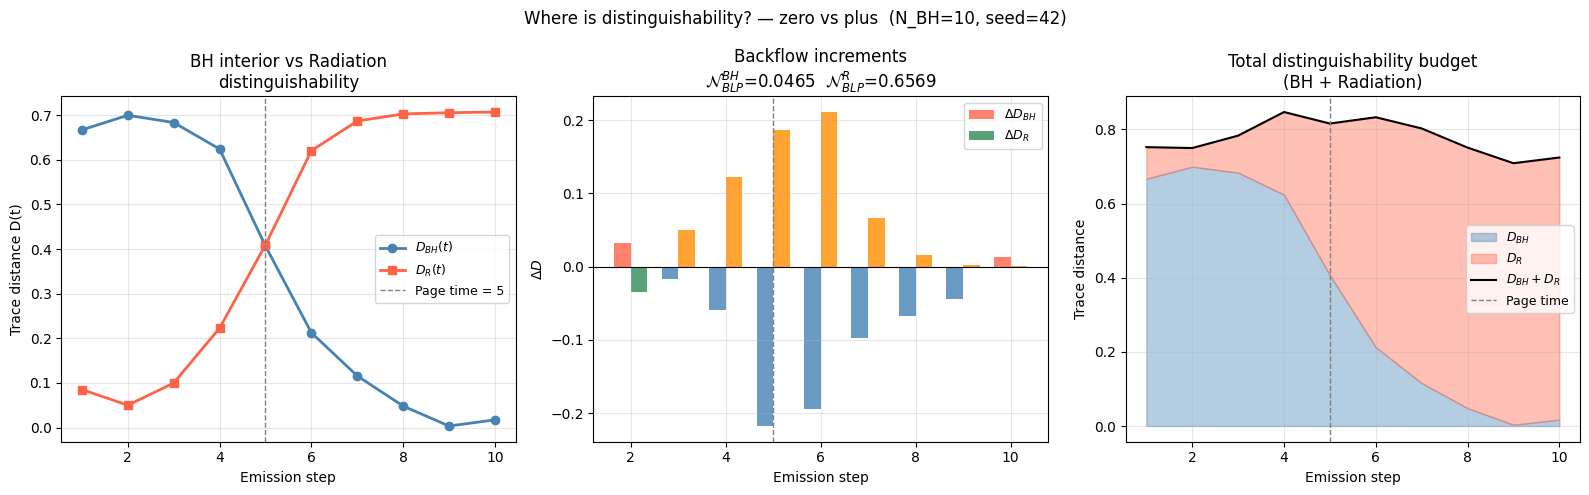

Saved: blp_bh_vs_radiation.pdf


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP DIAGNOSTIC: D_BH(t) vs D_R(t)
# Where is the distinguishability living — BH interior or radiation?
# ─────────────────────────────────────────────────────────────────────────────

DIAG_PROBE_A = 'zero'
DIAG_PROBE_B = 'plus'
DIAG_SEED    = 42

def run_evaporation_for_blp_radiation(probe: str, seed: int = 42,
                                       g0: float = G0_GLOBAL):
    """
    Same circuit as run_evaporation_for_blp but returns
    reduced RADIATION density matrix at each step.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)    # trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # final step: all is radiation
        rho_series.append(rho_rad)

    return rho_series


# ── Run both subsystems for the same probe pair and seed ─────────────────────
print(f"BH vs Radiation distinguishability diagnostic")
print(f"Probe A: {DIAG_PROBE_A}  |  Probe B: {DIAG_PROBE_B}  |  seed={DIAG_SEED}")
print(f"N_BH = {N_BH}  |  Page time ≈ step {N_BH // 2}\n")

# BH interior series (already have this function)
rho_bh_a = run_evaporation_for_blp(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_bh_b = run_evaporation_for_blp(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

# Radiation series
rho_rad_a = run_evaporation_for_blp_radiation(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_rad_b = run_evaporation_for_blp_radiation(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

T      = min(len(rho_bh_a), len(rho_bh_b), len(rho_rad_a), len(rho_rad_b))
steps  = list(range(1, T + 1))

D_BH  = [trace_distance(rho_bh_a[t],  rho_bh_b[t])  for t in range(T)]
D_R   = [trace_distance(rho_rad_a[t], rho_rad_b[t]) for t in range(T)]
D_sum = [D_BH[t] + D_R[t] for t in range(T)]

dD_BH = np.diff(D_BH)
dD_R  = np.diff(D_R)

N_BLP_BH = float(np.sum(dD_BH[dD_BH > 0]))
N_BLP_R  = float(np.sum(dD_R[dD_R   > 0]))

page_step = N_BH // 2

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Step':>5}  {'D_BH(t)':>10}  {'D_R(t)':>10}  "
      f"{'D_BH+D_R':>10}  {'ΔD_BH':>8}  {'ΔD_R':>8}  {'era':>12}")
print("─" * 75)
for i, t in enumerate(steps):
    era  = "pre-Page " if t <= page_step else "post-Page"
    dBH  = f"{dD_BH[i-1]:+.5f}" if i > 0 else "    —    "
    dR   = f"{dD_R[i-1]:+.5f}"  if i > 0 else "    —    "
    print(f"{t:>5}  {D_BH[i]:>10.6f}  {D_R[i]:>10.6f}  "
          f"{D_sum[i]:>10.6f}  {dBH:>8}  {dR:>8}  {era:>12}")

print(f"\nN_BLP (BH interior)  = {N_BLP_BH:.6f}")
print(f"N_BLP (radiation)    = {N_BLP_R:.6f}")
print()

# ── Interpret ─────────────────────────────────────────────────────────────────
post_page_D_BH = [D_BH[i]  for i, t in enumerate(steps) if t > page_step]
post_page_D_R  = [D_R[i]   for i, t in enumerate(steps) if t > page_step]

print("Distinguishability after Page time:")
print(f"  Mean D_BH (post-Page) = {np.mean(post_page_D_BH):.6f}")
print(f"  Mean D_R  (post-Page) = {np.mean(post_page_D_R):.6f}")

if np.mean(post_page_D_R) > np.mean(post_page_D_BH):
    print("\n  → Distinguishability has migrated to radiation after Page time.")
    print("    Information left the BH interior and is encoded in radiation.")
    print("    BLP_BH detects only early-time backflow; late-time info is in R.")
elif np.mean(post_page_D_R) < 1e-4 and np.mean(post_page_D_BH) < 1e-4:
    print("\n  → Both D_BH and D_R near zero post-Page.")
    print("    Scrambler has erased initial condition globally.")
    print("    Neither subsystem retains probe-state distinguishability.")
else:
    print("\n  → Mixed picture — check individual step values.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: D_BH and D_R together
axes[0].plot(steps, D_BH, 'o-', color='steelblue', lw=2, label=r'$D_{BH}(t)$')
axes[0].plot(steps, D_R,  's-', color='tomato',    lw=2, label=r'$D_{R}(t)$')
axes[0].axvline(page_step, color='gray', ls='--', lw=1, label=f'Page time = {page_step}')
axes[0].set_xlabel("Emission step")
axes[0].set_ylabel("Trace distance D(t)")
axes[0].set_title("BH interior vs Radiation\ndistinguishability")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Middle: ΔD_BH and ΔD_R (backflow increments)
bar_x = steps[1:]
w = 0.35
axes[1].bar([x - w/2 for x in bar_x], dD_BH,
            width=w, color=['tomato' if d > 0 else 'steelblue' for d in dD_BH],
            alpha=0.8, label=r'$\Delta D_{BH}$')
axes[1].bar([x + w/2 for x in bar_x], dD_R,
            width=w, color=['darkorange' if d > 0 else 'seagreen' for d in dD_R],
            alpha=0.8, label=r'$\Delta D_{R}$')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(page_step, color='gray', ls='--', lw=1)
axes[1].set_xlabel("Emission step")
axes[1].set_ylabel(r"$\Delta D$")
axes[1].set_title(
    r"Backflow increments" + "\n"
    r"$\mathcal{N}_{BLP}^{BH}$=" + f"{N_BLP_BH:.4f}  "
    r"$\mathcal{N}_{BLP}^{R}$=" + f"{N_BLP_R:.4f}"
)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Right: D_BH + D_R (total distinguishability budget)
axes[2].fill_between(steps, 0,        D_BH,  alpha=0.4, color='steelblue',
                     label=r'$D_{BH}$')
axes[2].fill_between(steps, D_BH, D_sum, alpha=0.4, color='tomato',
                     label=r'$D_{R}$')
axes[2].plot(steps, D_sum, 'k-', lw=1.5, label=r'$D_{BH}+D_{R}$')
axes[2].axvline(page_step, color='gray', ls='--', lw=1, label=f'Page time')
axes[2].set_xlabel("Emission step")
axes[2].set_ylabel("Trace distance")
axes[2].set_title("Total distinguishability budget\n(BH + Radiation)")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle(
    f"Where is distinguishability? — {DIAG_PROBE_A} vs {DIAG_PROBE_B}  "
    f"(N_BH={N_BH}, seed={DIAG_SEED})",
    fontsize=12
)
plt.tight_layout()
plt.savefig("blp_bh_vs_radiation.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_bh_vs_radiation.pdf")

KRYLOV SPREAD COMPLEXITY — MAIN RUN
N_BH = 10  |  G0_GLOBAL = 0.785  |  Page time = step 5

────────────────────────────────────────────────────────────
Running Non-Markovian evaporation  (seed=42, g0=0.785)
  State history length : 11 vectors
  Krylov chain dim D   : 11
  Lanczos b_n          : ['1.0000', '0.9998', '0.9996', '0.9983', '0.9986', '0.9984', '0.9976', '0.9970', '0.9951', '0.9969', '0.9956']

  Step      C_K      p_0      p_1      p_2      p_3
  ─────────────────────────────────────────────
     0    0.000    1.000    0.000    0.000    0.000
     1    1.000    0.000    1.000    0.000    0.000
     2    1.999    0.000    0.000    0.999    0.000
     3    2.994    0.000    0.002    0.002    0.997
     4    3.995    0.000    0.000    0.001    0.002
     5    4.991    0.001    0.001    0.000    0.000
     6    5.988    0.000    0.001    0.001    0.000
     7    6.978    0.002    0.000    0.001    0.000
     8    7.952    0.003    0.000    0.000    0.002
     9    8.963    0.00

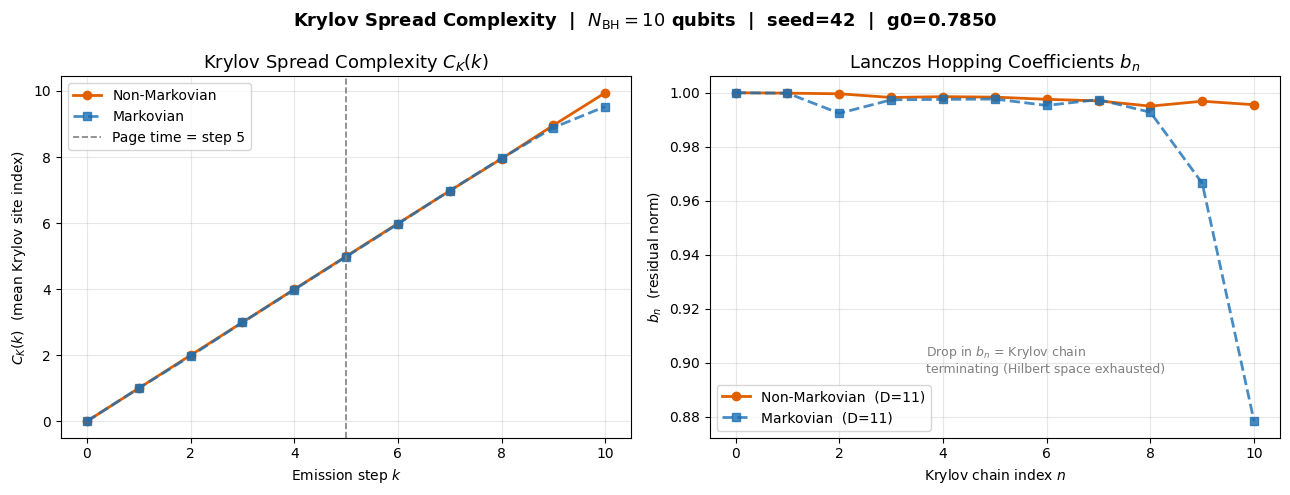

Saved: krylov_spread_complexity.pdf

Krylov Seed Robustness  (N_BH=10, g0=0.7850)
Page time = step 5

  Seed    C_K(page) NM   C_K(page) M    ΔC_K(page)   C_K(final) NM   C_K(final) M   ΔC_K(final)
────────────────────────────────────────────────────────────────────────────────────────────────────
     0          4.9888        4.9928       -0.0040          9.9259         9.5436       +0.3823
     7          4.9814        4.9928       -0.0114          9.9212         9.7913       +0.1300
    42          4.9906        4.9833       +0.0073          9.9467         9.5302       +0.4165
    99          4.9908        4.9821       +0.0086          9.9528         9.2401       +0.7127
   123          4.9900        4.9759       +0.0141          9.9586         9.6540       +0.3046
────────────────────────────────────────────────────────────────────────────────────────────────────
  mean                                                                                  +0.3892
   std                  

In [45]:
# =============================================================================
# KRYLOV SPREAD COMPLEXITY — FULL IMPLEMENTATION
# =============================================================================
#
# Theory:
#   Balasubramanian, Caputa, Magan, Wu
#   "Quantum chaos and the complexity of spread of states"
#   Phys. Rev. D 106, 046007 (2022)  [arXiv:2202.06957]
#
# Discrete / circuit adaptation:
#   Parker, Cao, Avdoshkin, Scaffidi, Altman
#   "A universal operator growth hypothesis"
#   Phys. Rev. X 9, 041017 (2019)
#
#   Open-system generalization (motivation for Markovian control):
#   Liu, Tang, Zhai
#   "Krylov complexity in open quantum systems"
#   Phys. Rev. Research 5, 033085 (2023)
#
# Physical argument for our approach:
#   Standard spread complexity requires a fixed Hamiltonian H to build
#   the Krylov basis via Lanczos recursion on H^k|psi_0>.
#   Our model has NO fixed H — each emission step applies a different
#   random circuit U_k. The appropriate generalization is to build the
#   Krylov basis by Gram-Schmidt orthogonalization of the evolved state
#   TRAJECTORY {|psi_0>, |psi_1>, ..., |psi_N>}.
#
#   Justification: By definition, e^{-iHt}|psi_0> = sum_k c_k H^k|psi_0>,
#   so the Krylov subspace IS span{|psi_0>, |psi(t_1)>, ...}.
#   For our discrete circuit, |psi_k> = U_k...U_1|psi_0> plays the same
#   role. The Gram-Schmidt construction gives the optimal (minimum-spread)
#   orthonormal basis for this subspace — the discrete Krylov basis.
#
# Derivation of the formula:
#   1. Krylov basis: {|K_0>, |K_1>, ..., |K_{D-1}>} built by Gram-Schmidt
#      of {|psi_0>, |psi_1>, ..., |psi_N>}
#      |K_0> = |psi_0>
#      |tilde_K_n> = |psi_n> - sum_{j<n} <K_j|psi_n> |K_j>
#      b_n = ||tilde_K_n||  (Lanczos hopping coefficient)
#      |K_n> = |tilde_K_n> / b_n
#
#   2. Krylov amplitudes at step k:
#      phi_n(k) = <K_n|psi_k>
#
#   3. Spread complexity:
#      C_K(k) = sum_n n * |phi_n(k)|^2   (mean site index on Krylov chain)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy


# =============================================================================
# SECTION 1: EVAPORATION RUNNER — RETURNS FULL STATEVECTOR SEQUENCE
# =============================================================================

def run_evaporation_statevectors(seed: int = 42,
                                  markovian: bool = False,
                                  g0: float = None):
    """
    Run one complete evaporation and return the full global statevector
    at each emission step.

    Returns
    -------
    state_history : list of np.ndarray, shape (2^N_BH,), complex
                    Index 0 = initial state BEFORE any emission.
                    Index k = state after k emission steps.
    """
    if g0 is None:
        g0 = G0_GLOBAL

    np.random.seed(seed)
    state = Statevector.from_label('0' * N_BH)
    state_history = [np.array(state.data, dtype=complex)]

    bh  = list(range(N_BH))
    rad = []

    while len(bh) > 0:
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)

        if not markovian and len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if not markovian and len(rad) > 0:
            bh_radiation_backaction(
                step_qc, bh, rad,
                t=len(rad), N_BH_total=N_BH, g0=g0
            )

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)
        state_history.append(np.array(state.data, dtype=complex))

    return state_history


# =============================================================================
# SECTION 2: GRAM-SCHMIDT KRYLOV BASIS CONSTRUCTION
# =============================================================================

def build_krylov_basis(state_history: list, tol: float = 1e-10):
    """
    Build the discrete Krylov basis by Gram-Schmidt orthogonalization
    of the state trajectory.

    Returns
    -------
    krylov_basis : list of np.ndarray — orthonormal Krylov basis vectors
    b_coeffs     : list of float — Lanczos hopping coefficients b_n
                   b_n = residual norm before normalization at step n.
                   Encodes how much genuinely new Hilbert space each
                   emission step explores.
    chain_dim    : int — effective Krylov chain dimension D
    """
    krylov_basis = []
    b_coeffs     = []

    for psi in state_history:
        vec = psi.copy()
        norm_init = np.linalg.norm(vec)
        if norm_init < 1e-14:
            continue
        vec = vec / norm_init

        for K_j in krylov_basis:
            overlap = np.vdot(K_j, vec)
            vec = vec - overlap * K_j

        b_n = np.linalg.norm(vec)
        b_coeffs.append(float(b_n))

        if b_n < tol:
            break

        krylov_basis.append(vec / b_n)

    chain_dim = len(krylov_basis)
    return krylov_basis, b_coeffs, chain_dim


# =============================================================================
# SECTION 3: SPREAD COMPLEXITY COMPUTATION
# =============================================================================

def compute_spread_complexity(state_history: list, krylov_basis: list):
    """
    Compute Krylov spread complexity at each step.
    C_K(k) = sum_{n=0}^{D-1} n * |<K_n | psi_k>|^2

    Returns
    -------
    C_K       : np.ndarray — spread complexity
    prob_dist : np.ndarray, shape (N_steps, D) — full Krylov distribution
    """
    N_steps   = len(state_history)
    D         = len(krylov_basis)
    C_K       = np.zeros(N_steps)
    prob_dist = np.zeros((N_steps, D))
    n_indices = np.arange(D)

    for k, psi_k in enumerate(state_history):
        norm = np.linalg.norm(psi_k)
        if norm < 1e-14:
            continue
        psi_k_norm = psi_k / norm

        phi          = np.array([np.vdot(K_n, psi_k_norm) for K_n in krylov_basis])
        p            = np.abs(phi)**2
        prob_dist[k] = p
        C_K[k]       = float(np.dot(n_indices, p))

    return C_K, prob_dist


# =============================================================================
# SECTION 4: FULL PIPELINE — NM vs MARKOVIAN
# =============================================================================

def run_krylov_analysis(seed: int = 42, g0: float = None,
                         tol: float = 1e-10, verbose: bool = True):
    """Full Krylov spread complexity analysis: NM vs Markovian."""
    if g0 is None:
        g0 = G0_GLOBAL

    results = {}

    for label, markovian in [('nm', False), ('markovian', True)]:
        tag = 'Non-Markovian' if not markovian else 'Markovian'
        if verbose:
            print(f"\n{'─'*60}")
            print(f"Running {tag} evaporation  (seed={seed}, g0={g0:.3f})")

        state_history = run_evaporation_statevectors(
            seed=seed, markovian=markovian, g0=g0)

        krylov_basis, b_coeffs, chain_dim = build_krylov_basis(
            state_history, tol=tol)

        C_K, prob_dist = compute_spread_complexity(state_history, krylov_basis)

        if verbose:
            print(f"  State history length : {len(state_history)} vectors")
            print(f"  Krylov chain dim D   : {chain_dim}")
            print(f"  Lanczos b_n          : "
                  f"{[f'{b:.4f}' for b in b_coeffs[:chain_dim]]}")
            print(f"\n  {'Step':>4}  {'C_K':>7}  {'p_0':>7}  {'p_1':>7}  "
                  f"{'p_2':>7}  {'p_3':>7}")
            print(f"  {'─'*45}")
            for k in range(len(state_history)):
                p_str = '  '.join(f'{prob_dist[k,n]:>7.3f}'
                                   for n in range(min(4, chain_dim)))
                print(f"  {k:>4}  {C_K[k]:>7.3f}  {p_str}")

        results[label] = {
            'state_history': state_history,
            'krylov_basis':  krylov_basis,
            'b_coeffs':      b_coeffs,
            'chain_dim':     chain_dim,
            'C_K':           C_K,
            'prob_dist':     prob_dist,
            'steps':         np.arange(len(state_history)),
        }

    return results


# =============================================================================
# SECTION 5: SEED ROBUSTNESS TABLE
# =============================================================================

def krylov_seed_robustness(seeds=None, g0=None, tol=1e-10):
    """
    C_K at final step across multiple seeds — NM vs Markovian.
    Reports ΔC_K = C_K_NM - C_K_M (non-Markovian excess complexity).
    Page-time column retained for reference but verdict based on final step.
    """
    if seeds is None:
        seeds = [0, 7, 42, 99, 123]
    if g0 is None:
        g0 = G0_GLOBAL

    page_step = N_BH // 2

    print(f"\nKrylov Seed Robustness  (N_BH={N_BH}, g0={g0:.4f})")
    print(f"Page time = step {page_step}")
    print(f"\n{'Seed':>6}  {'C_K(page) NM':>14}  {'C_K(page) M':>12}  "
          f"{'ΔC_K(page)':>12}  {'C_K(final) NM':>14}  "
          f"{'C_K(final) M':>13}  {'ΔC_K(final)':>12}")
    print("─" * 100)

    delta_final_list = []

    for seed in seeds:
        res = run_krylov_analysis(seed=seed, g0=g0, tol=tol, verbose=False)
        ck_nm_page  = res['nm']['C_K'][page_step]
        ck_m_page   = res['markovian']['C_K'][page_step]
        ck_nm_final = res['nm']['C_K'][-1]
        ck_m_final  = res['markovian']['C_K'][-1]
        d_page      = ck_nm_page  - ck_m_page
        d_final     = ck_nm_final - ck_m_final
        delta_final_list.append(d_final)
        print(f"{seed:>6}  {ck_nm_page:>14.4f}  {ck_m_page:>12.4f}  "
              f"{d_page:>+12.4f}  {ck_nm_final:>14.4f}  "
              f"{ck_m_final:>13.4f}  {d_final:>+12.4f}")

    print("─" * 100)
    print(f"{'mean':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.mean(delta_final_list):>+12.4f}")
    print(f"{'std':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.std(delta_final_list):>+12.4f}")

    nm_final_robust = np.all(np.array(delta_final_list) > 0)
    print(f"\nVerdict: NM > Markovian at final step on ALL seeds: "
          f"{'YES — robust NM complexity excess' if nm_final_robust else 'NO — not consistent'}")

    return delta_final_list


# =============================================================================
# SECTION 6: PLOTTING — 2 PANELS ONLY
# =============================================================================

def plot_krylov_results(results: dict, seed: int = 42):
    """
    2-panel figure: C_K(k) and Lanczos b_n coefficients.
    Panels 2 (normalized C_bar) and 3 (survival probability) removed —
    both were shown to carry no additional information for this model.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    page_step = N_BH // 2

    nm_res = results['nm']
    m_res  = results['markovian']
    steps  = nm_res['steps']

    # ── Panel 1: Raw spread complexity ───────────────────────────────────────
    ax = axes[0]
    ax.plot(steps, nm_res['C_K'], 'o-',  color=C_NM, lw=2,
            label='Non-Markovian')
    ax.plot(steps, m_res['C_K'],  's--', color=C_M,  lw=2, alpha=0.8,
            label='Markovian')
    ax.axvline(page_step, color='gray', ls='--', lw=1.2,
               label=f'Page time = step {page_step}')
    ax.set_title(r'Krylov Spread Complexity $C_K(k)$', fontsize=13)
    ax.set_xlabel('Emission step $k$')
    ax.set_ylabel(r'$C_K(k)$  (mean Krylov site index)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    # ── Panel 2: Lanczos b_n coefficients ────────────────────────────────────
    ax = axes[1]
    nm_b = nm_res['b_coeffs'][:nm_res['chain_dim']]
    m_b  = m_res['b_coeffs'][:m_res['chain_dim']]
    ax.plot(range(len(nm_b)), nm_b, 'o-',  color=C_NM, lw=2,
            label=f"Non-Markovian  (D={nm_res['chain_dim']})")
    ax.plot(range(len(m_b)),  m_b,  's--', color=C_M,  lw=2, alpha=0.8,
            label=f"Markovian  (D={m_res['chain_dim']})")
    ax.set_title(r'Lanczos Hopping Coefficients $b_n$', fontsize=13)
    ax.set_xlabel('Krylov chain index $n$')
    ax.set_ylabel(r'$b_n$  (residual norm)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.annotate(
        'Drop in $b_n$ = Krylov chain\nterminating (Hilbert space exhausted)',
        xy=(0.38, 0.18), xycoords='axes fraction', fontsize=9, color='gray'
    )

    plt.suptitle(
        f'Krylov Spread Complexity  |  $N_{{\\rm BH}}={N_BH}$ qubits  |  '
        f'seed={seed}  |  g0={G0_GLOBAL:.4f}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('krylov_spread_complexity.pdf', bbox_inches='tight', dpi=200)
    plt.show()
    print("Saved: krylov_spread_complexity.pdf")


# =============================================================================
# SECTION 7: MAIN EXECUTION
# =============================================================================

print("=" * 70)
print("KRYLOV SPREAD COMPLEXITY — MAIN RUN")
print(f"N_BH = {N_BH}  |  G0_GLOBAL = {G0_GLOBAL}  |  Page time = step {N_BH//2}")
print("=" * 70)

# ── 1. Single seed full analysis ─────────────────────────────────────────────
results = run_krylov_analysis(seed=42, g0=G0_GLOBAL, verbose=True)

# ── 2. Plots ─────────────────────────────────────────────────────────────────
plot_krylov_results(results, seed=42)

# ── 3. Seed robustness table (final-step verdict only) ───────────────────────
delta_final = krylov_seed_robustness(seeds=[0, 7, 42, 99, 123], g0=G0_GLOBAL)

# ── 4. Summary ───────────────────────────────────────────────────────────────
nm = results['nm']
m  = results['markovian']

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Krylov chain dimension:  NM = {nm['chain_dim']}   "
      f"Markovian = {m['chain_dim']}")
print(f"C_K at Page time (k={N_BH//2}):")
print(f"  Non-Markovian : {nm['C_K'][N_BH//2]:.4f}")
print(f"  Markovian     : {m['C_K'][N_BH//2]:.4f}")
print(f"  Difference    : {nm['C_K'][N_BH//2] - m['C_K'][N_BH//2]:+.4f}")
print(f"C_K at final step (k={N_BH}):")
print(f"  Non-Markovian : {nm['C_K'][-1]:.4f}")
print(f"  Markovian     : {m['C_K'][-1]:.4f}")
print(f"  Difference    : {nm['C_K'][-1] - m['C_K'][-1]:+.4f}")
print("=" * 70)